# Data Exploration
WMH 2017 Challenge Dataset

Goals of this notebook:
1. Understand the folder structure and count cases per site
2. Check image shapes, spacings, and orientations across sites
3. Check WMH mask values and lesion statistics
4. Visualize T1, FLAIR, and WMH mask side by side for a few patients
5. Flag any anomalies

In [1]:
import os
import glob
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import random

# NOTE: Change this to match your data root
DATA_ROOT = Path('/data/users/ssethi2/mmml_repos/guided-brightspot/data/wmh_data/training')

# There are 3 sites where the data was collected
SITES = ['Utrecht', 'Singapore', 'Amsterdam/GE3T']                      # Amsterdam has extra subdir

assert(DATA_ROOT.exists())

## 1. Count cases and build a case list

In [2]:
# Note: Each patient has a pre/ and orig/ subdir with the FLAIR and T1
# pre/ = preprocessed (bias corrected, registered) — this is what I check in this notebook

cases = [] 

for site in SITES:
    site_dir = DATA_ROOT / site
    if not site_dir.exists():
        print(f'WARNING: {site} directory not found')
        continue
    patient_ids = sorted(os.listdir(site_dir))
    print(f'{site}: {len(patient_ids)} patients -> {patient_ids}')
    for pid in patient_ids:
        case = {
            'site': site,
            'patient_id': pid,
            'flair': site_dir / pid / 'pre' / 'FLAIR.nii',
            't1':    site_dir / pid / 'pre' / 'T1.nii',
            'wmh':   site_dir / pid / 'wmh.nii',
        }
        # check all files exist
        missing = [k for k, v in case.items() if isinstance(v, Path) and not v.exists()]
        if missing:
            print(f'  WARNING {site}/{pid} missing: {missing}')
        else:
            cases.append(case)

print(f'\nTotal usable cases: {len(cases)}')

Utrecht: 20 patients -> ['0', '11', '17', '19', '2', '21', '23', '25', '27', '29', '31', '33', '35', '37', '39', '4', '41', '49', '6', '8']
Singapore: 20 patients -> ['50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69']
Amsterdam/GE3T: 20 patients -> ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '112', '113', '114', '115', '116', '126', '132', '137', '144']

Total usable cases: 60


In [3]:
print("Example Case: (Contains site, patient_ID and paths to 3 relevant files)")
cases[0]

Example Case: (Contains site, patient_ID and paths to 3 relevant files)


{'site': 'Utrecht',
 'patient_id': '0',
 'flair': PosixPath('/data/users/ssethi2/mmml_repos/guided-brightspot/data/wmh_data/training/Utrecht/0/pre/FLAIR.nii'),
 't1': PosixPath('/data/users/ssethi2/mmml_repos/guided-brightspot/data/wmh_data/training/Utrecht/0/pre/T1.nii'),
 'wmh': PosixPath('/data/users/ssethi2/mmml_repos/guided-brightspot/data/wmh_data/training/Utrecht/0/wmh.nii')}

## 2. Check image shapes, spacings, and orientations across all cases

In [4]:
# Information we want:
# - Spacing --> "distance between pixels along each dimension of the image in the physical world coordinate system."
# - Size --> "the number of pixels the Image is in each dimension"

def get_image_info(path):
    img = sitk.ReadImage(str(path))
    return {
        'size': img.GetSize(),
        'spacing': tuple(round(s, 3) for s in img.GetSpacing()),
        'origin': tuple(round(o, 1) for o in img.GetOrigin()),
        'direction': img.GetDirection(),
    }

print(f"{'Site':<12} {'PID':<6} {'FLAIR shape':<20} {'FLAIR spacing':<25} {'T1 shape':<20} {'T1 spacing'}")
print('-' * 100)

shapes = defaultdict(set)
spacings = defaultdict(set)

for case in cases:
    flair_info = get_image_info(case['flair'])
    t1_info    = get_image_info(case['t1'])
    site = case['site']
    
    shapes[site].add(flair_info['size'])
    spacings[site].add(flair_info['spacing'])
    
    print(f"{site:<12} {case['patient_id']:<6} {str(flair_info['size']):<20} {str(flair_info['spacing']):<25} {str(t1_info['size']):<20} {str(t1_info['spacing'])}")

Site         PID    FLAIR shape          FLAIR spacing             T1 shape             T1 spacing
----------------------------------------------------------------------------------------------------
Utrecht      0      (240, 240, 48)       (0.958, 0.958, 3.0)       (240, 240, 48)       (0.958, 0.958, 3.0)
Utrecht      11     (240, 240, 48)       (0.958, 0.958, 3.0)       (240, 240, 48)       (0.958, 0.958, 3.0)
Utrecht      17     (240, 240, 48)       (0.958, 0.958, 3.0)       (240, 240, 48)       (0.958, 0.958, 3.0)
Utrecht      19     (240, 240, 48)       (0.958, 0.958, 3.0)       (240, 240, 48)       (0.958, 0.958, 3.0)
Utrecht      2      (240, 240, 48)       (0.958, 0.958, 3.0)       (240, 240, 48)       (0.958, 0.958, 3.0)
Utrecht      21     (240, 240, 48)       (0.958, 0.958, 3.0)       (240, 240, 48)       (0.958, 0.958, 3.0)
Utrecht      23     (240, 240, 48)       (0.958, 0.958, 3.0)       (240, 240, 48)       (0.958, 0.958, 3.0)
Utrecht      25     (240, 240, 48)       (0.

In [5]:
# This tells us that we need to standardize since these are not the same across (or even within) sites:

print('\n--- Unique FLAIR shapes per site ---')
for site, sh in shapes.items():
    print(f'  {site}: {sh}')

print('\n--- Unique FLAIR spacings per site ---')
for site, sp in spacings.items():
    print(f'  {site}: {sp}')


--- Unique FLAIR shapes per site ---
  Utrecht: {(240, 240, 48)}
  Singapore: {(256, 232, 48), (232, 256, 48)}
  Amsterdam/GE3T: {(132, 256, 83)}

--- Unique FLAIR spacings per site ---
  Utrecht: {(0.958, 0.958, 3.0)}
  Singapore: {(1.0, 1.0, 3.0)}
  Amsterdam/GE3T: {(1.2, 0.977, 3.0)}


## 3. Check WMH mask values and lesion load statistics

In [6]:
wmh_stats = []

for case in cases:
    wmh_img = sitk.ReadImage(str(case['wmh']))
    wmh_arr = sitk.GetArrayFromImage(wmh_img)
    
    unique_vals = np.unique(wmh_arr)
    lesion_voxels = np.sum(wmh_arr > 0)
    total_voxels = wmh_arr.size
    spacing = wmh_img.GetSpacing()  # (x, y, z)
    voxel_vol_mm3 = spacing[0] * spacing[1] * spacing[2]
    lesion_vol_ml = (lesion_voxels * voxel_vol_mm3) / 1000
    
    wmh_stats.append({
        'site': case['site'],
        'pid': case['patient_id'],
        'unique_vals': unique_vals,
        'lesion_voxels': lesion_voxels,
        'lesion_vol_ml': round(lesion_vol_ml, 3),
        'shape': wmh_arr.shape,
    })

print(f"{'Site':<12} {'PID':<6} {'Unique mask vals':<25} {'Lesion voxels':<18} {'Lesion vol (ml)'}")
print('-' * 80)
for s in wmh_stats:
    print(f"{s['site']:<12} {s['pid']:<6} {str(s['unique_vals']):<25} {s['lesion_voxels']:<18} {s['lesion_vol_ml']}")


Site         PID    Unique mask vals          Lesion voxels      Lesion vol (ml)
--------------------------------------------------------------------------------
Utrecht      0      [0. 1. 2.]                19371              53.371
Utrecht      11     [0. 1. 2.]                2900               7.99
Utrecht      17     [0. 1. 2.]                1598               4.403
Utrecht      19     [0. 1. 2.]                14505              39.964
Utrecht      2      [0. 1.]                   11859              32.674
Utrecht      21     [0. 1.]                   9021               24.855
Utrecht      23     [0. 1.]                   332                0.915
Utrecht      25     [0. 1. 2.]                9404               25.91
Utrecht      27     [0. 1. 2.]                770                2.122
Utrecht      29     [0. 1. 2.]                16906              46.58
Utrecht      31     [0. 1.]                   24669              67.968
Utrecht      33     [0. 1.]                   1432   

In [7]:
# Summary stats
vols = [s['lesion_vol_ml'] for s in wmh_stats]
print(f'\nLesion volume (ml) — min: {min(vols):.3f}, max: {max(vols):.3f}, mean: {np.mean(vols):.3f}, std: {np.std(vols):.3f}')


Lesion volume (ml) — min: 0.915, max: 74.991, mean: 20.203, std: 19.278


In [8]:
# Check for any non-binary masks (Which we have to deal with)
non_binary = [s for s in wmh_stats if not set(s['unique_vals']).issubset({0, 1})]
if non_binary:
    print(f'\nWARNING: These cases have non-binary mask values:')
    for s in non_binary:
        print(f"  {s['site']}/{s['pid']}: {s['unique_vals']}")
else:
    print('\nAll masks are binary (0/1) — good!')


  Utrecht/0: [0. 1. 2.]
  Utrecht/11: [0. 1. 2.]
  Utrecht/17: [0. 1. 2.]
  Utrecht/19: [0. 1. 2.]
  Utrecht/25: [0. 1. 2.]
  Utrecht/27: [0. 1. 2.]
  Utrecht/29: [0. 1. 2.]
  Utrecht/4: [0. 1. 2.]
  Utrecht/41: [0. 1. 2.]
  Singapore/51: [0. 1. 2.]
  Singapore/54: [0. 1. 2.]
  Singapore/59: [0. 1. 2.]
  Singapore/60: [0. 1. 2.]
  Singapore/61: [0. 1. 2.]
  Singapore/62: [0. 1. 2.]
  Singapore/63: [0. 1. 2.]
  Singapore/64: [0. 1. 2.]
  Singapore/65: [0. 1. 2.]
  Singapore/67: [0. 1. 2.]
  Singapore/68: [0. 1. 2.]
  Amsterdam/GE3T/104: [0. 1. 2.]
  Amsterdam/GE3T/105: [0. 1. 2.]
  Amsterdam/GE3T/107: [0. 1. 2.]
  Amsterdam/GE3T/108: [0. 1. 2.]
  Amsterdam/GE3T/113: [0. 1. 2.]


## 4. Visualize T1, FLAIR, and WMH mask for one patient per site

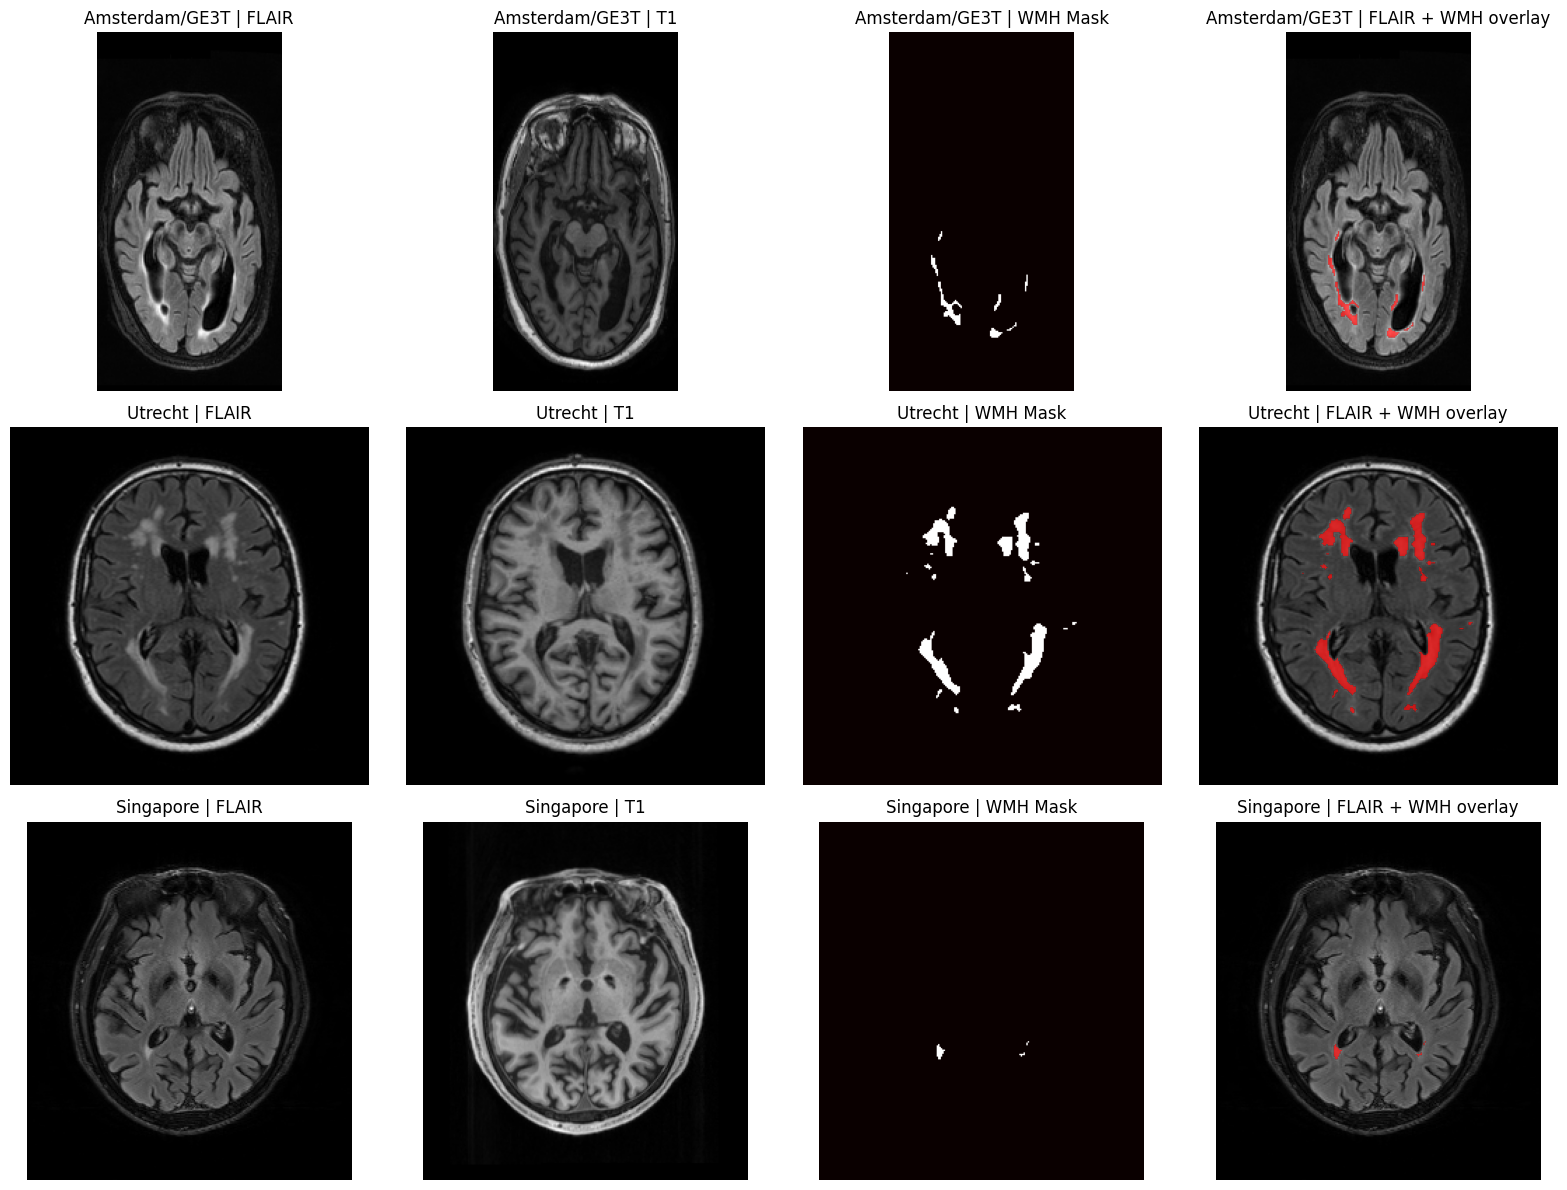

Saved to exploration_slices.png


In [9]:
def get_middle_slice(arr):
    """Return the middle axial slice (first dim in SimpleITK array = z)"""
    return arr[arr.shape[0] // 2, :, :]

def normalize(arr):
    """Normalize to 0-1 for display"""
    arr = arr.astype(float)
    if arr.max() == arr.min():
        return arr
    return (arr - arr.min()) / (arr.max() - arr.min())

# Pick one representative case per site
site_examples = {}
random.shuffle(cases)
for case in cases:
    if case['site'] not in site_examples:
        site_examples[case['site']] = case

fig, axes = plt.subplots(len(site_examples), 4, figsize=(16, 4 * len(site_examples)))
col_titles = ['FLAIR', 'T1', 'WMH Mask', 'FLAIR + WMH overlay']

for row_idx, (site, case) in enumerate(site_examples.items()):
    flair_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(case['flair'])))
    t1_arr    = sitk.GetArrayFromImage(sitk.ReadImage(str(case['t1'])))
    wmh_arr   = sitk.GetArrayFromImage(sitk.ReadImage(str(case['wmh'])))

    flair_slice = get_middle_slice(flair_arr)
    t1_slice    = get_middle_slice(t1_arr)
    wmh_slice   = get_middle_slice(wmh_arr)

    ax = axes[row_idx] if len(site_examples) > 1 else axes

    ax[0].imshow(normalize(flair_slice), cmap='gray')
    ax[0].set_title(f'{site} | FLAIR')

    ax[1].imshow(normalize(t1_slice), cmap='gray')
    ax[1].set_title(f'{site} | T1')

    ax[2].imshow(wmh_slice, cmap='hot')
    ax[2].set_title(f'{site} | WMH Mask')

    # Overlay: FLAIR as gray + WMH as red
    ax[3].imshow(normalize(flair_slice), cmap='gray')
    masked = np.ma.masked_where(wmh_slice == 0, wmh_slice)
    ax[3].imshow(masked, cmap='autumn', alpha=0.7)
    ax[3].set_title(f'{site} | FLAIR + WMH overlay')

    for a in ax:
        a.axis('off')

plt.tight_layout()
plt.savefig('exploration_slices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to exploration_slices.png')

## 5. Check intensity distributions across sites
Reason for this is if FLAIR intensity ranges differ widely across sites, we'll need normalization in the pipeline.

Amsterdam/GE3T FLAIR — min: 0.8, max: 1803.2, mean: 187.2, std: 251.6
Utrecht FLAIR — min: 2.4, max: 2287.4, mean: 354.9, std: 366.3
Singapore FLAIR — min: 0.7, max: 1750.1, mean: 87.8, std: 122.2


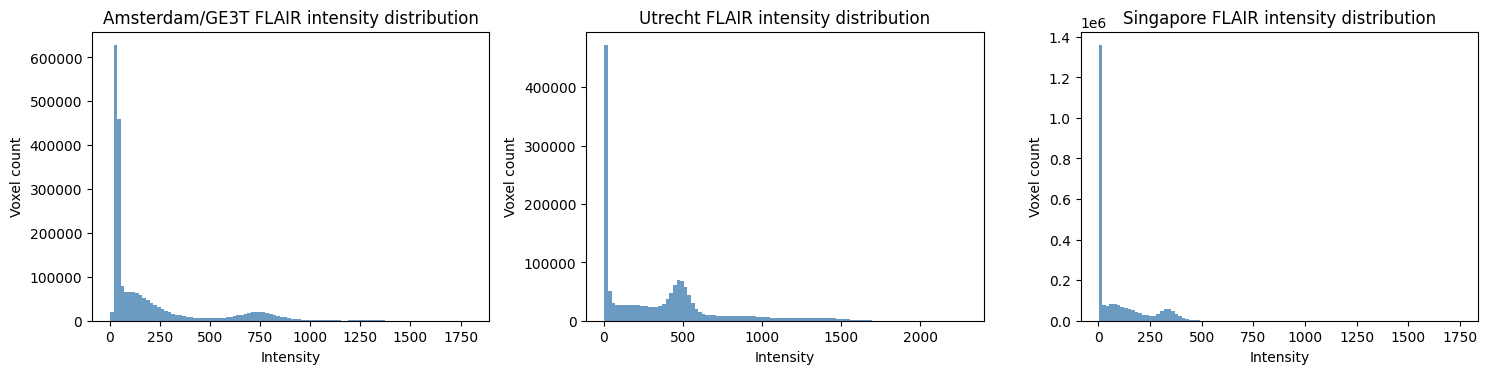

In [10]:
fig, axes = plt.subplots(1, len(site_examples), figsize=(15, 4))

for idx, (site, case) in enumerate(site_examples.items()):
    flair_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(case['flair']))).flatten()
    # Exclude zero background voxels for cleaner histogram
    flair_brain = flair_arr[flair_arr > 0]
    axes[idx].hist(flair_brain, bins=100, color='steelblue', alpha=0.8)
    axes[idx].set_title(f'{site} FLAIR intensity distribution')
    axes[idx].set_xlabel('Intensity')
    axes[idx].set_ylabel('Voxel count')
    print(f'{site} FLAIR — min: {flair_brain.min():.1f}, max: {flair_brain.max():.1f}, mean: {flair_brain.mean():.1f}, std: {flair_brain.std():.1f}')

plt.tight_layout()
plt.savefig('exploration_intensity_dists.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary — things to note before building the pipeline

In [11]:
print('=== SUMMARY ===')
print(f'Total cases: {len(cases)}')
for site in SITES:
    site_cases = [c for c in cases if c['site'] == site]
    print(f'  {site}: {len(site_cases)} cases')

print(f'\nUnique shapes across dataset:')
for site, sh in shapes.items():
    print(f'  {site}: {sh}')

print(f'\nUnique spacings across dataset:')
for site, sp in spacings.items():
    print(f'  {site}: {sp}')

print('\nThings to handle in the pipeline:')
print('  1. Resample all images to a common spacing (since spacings differ across sites)')
print('  2. Normalize FLAIR intensities (z-score per patient recommended)')
print('  3. Confirm mask binarization strategy (0 vs >0)')
print('  4. Use pre/ folder (not orig/) for all inputs')

=== SUMMARY ===
Total cases: 60
  Utrecht: 20 cases
  Singapore: 20 cases
  Amsterdam/GE3T: 20 cases

Unique shapes across dataset:
  Utrecht: {(240, 240, 48)}
  Singapore: {(256, 232, 48), (232, 256, 48)}
  Amsterdam/GE3T: {(132, 256, 83)}

Unique spacings across dataset:
  Utrecht: {(0.958, 0.958, 3.0)}
  Singapore: {(1.0, 1.0, 3.0)}
  Amsterdam/GE3T: {(1.2, 0.977, 3.0)}

Things to handle in the pipeline:
  1. Resample all images to a common spacing (since spacings differ across sites)
  2. Normalize FLAIR intensities (z-score per patient recommended)
  3. Confirm mask binarization strategy (0 vs >0)
  4. Use pre/ folder (not orig/) for all inputs
